In [133]:
import pandas as pd

In [134]:
df=pd.read_csv("../data/Clean_marketing_campaign_data.csv")

In [135]:
df.shape

(56000, 28)

In [136]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country'],
      dtype='object')

In [137]:
original_df = df.copy()

In [138]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Response               0
Complain               0
Country                0
dtype: int64

Feature Engineering

Final Recommended Features (13)

Age
Total_Spend
Total_Purchases
Children
Family_Size
Customer_Tenure
Total_Accepted_Campaigns
Purchase_Frequency
Web_Engagement
Income_Group
Engagement_Segment
Spending_Segment
Response_Segment
High_Value
Loyal_Customer
At_Risk
New_Customer

Original Business Columns
Income
Recency
MntWines
MntMeatProducts
NumWebPurchases
Response
Country
Education
Marital_Status


In [139]:
# create Age
df['Age'] = 2024 - df['Year_Birth']

In [140]:
print(min(df['Age']))

28


In [143]:
df['Age'].unique()

array([39, 49, 46, 48, 43, 47, 64, 28, 60, 56, 72, 59, 71, 84, 58, 45, 42,
       65, 40, 63, 29, 68, 37, 55, 41, 51, 66, 44, 36, 79, 54, 62, 53, 35,
       57, 69, 38, 50, 67, 52, 31, 75, 34, 77, 33, 82, 73, 81, 85, 70, 61,
       78, 30, 76, 74, 86, 80, 32, 83, 87, 88])

In [144]:
df['Age'].describe()

count    56000.000000
mean        52.333304
std         12.211066
min         28.000000
25%         43.000000
50%         51.000000
75%         61.000000
max         88.000000
Name: Age, dtype: float64

In [145]:
#Total_Spent
df["Total_Spend"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)

Total Purchases By the customer

In [146]:
#Total Purchases
df["Total_Purchases"] = (
    df["NumWebPurchases"]
    + df["NumCatalogPurchases"]
    + df["NumStorePurchases"]
)

In [149]:
#Children
df["Children"] = (
    df["Kidhome"]
    + df["Teenhome"]
)

In [152]:
#Age_Group

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[18,30,45,60,100],
    labels=[
        "Children"
        "Young",
        "Adult",
        "Middle_Age",
        "Senior"
    ]
)

Logic=Customer+spouse+kids

Family Size

In [153]:
#Famliy_Size
df["Family_Size"] = (
    df["Kidhome"]
    + df["Teenhome"]
    + 2
)


Simplify with Marital _status

In [155]:
df["Marital_Status"] = df["Marital_Status"].replace({
    "Married": "Partner",
    "Together": "Partner",
    
    "Single": "Alone",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Alone": "Alone",
    "Absurd": "Alone",
    "YOLO": "Alone"
})

Most Important Business Feature
Customer Tenure

 with How many days Coustomer connect with Compnay


In [156]:
df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"]
)

latest_date = df["Dt_Customer"].max()

df["Customer_Tenure"] = (
    latest_date
    - df["Dt_Customer"]
).dt.days

Total Accepted Campaigns
Best Features for Compaign Analytics

In [157]:
df["Total_Accepted_Campaigns"] = (
    df["AcceptedCmp1"]
    + df["AcceptedCmp2"]
    + df["AcceptedCmp3"]
    + df["AcceptedCmp4"]
    + df["AcceptedCmp5"]
)

Customer Segment (Business Feature)

In [158]:
df["Customer_Segment"] = "Normal"

df.loc[
    df["Income"] > 75000,
    "Customer_Segment"
] = "High Income"

df.loc[
    df["Total_Spend"] > 1000,
    "Customer_Segment"
] = "High Spender"

Customer purched Frequency 
Customer is Active or not

In [159]:
df["Purchase_Frequency"] = (
    df["Total_Purchases"]
    / (df["Recency"] + 1)
)

Web Engagement
 What is the behaviour of Web Engagement?

In [160]:
#Web Engagement
df["Web_Engagement"] = (
    df["NumWebVisitsMonth"]
    / (df["Total_Purchases"] + 1)
)

In [161]:
#Is Parents or Not
df["Is_Parent"] = (
    df["Children"] > 0
).astype(int)

In [162]:
#Income Group
df['Income_Group'] = pd.cut(df['Income'],
                           bins=[0,30000,60000,100000],
                           labels=['Low','Medium','High'])#

In [163]:
# Engagement Segment
df['Engagement_Segment'] = 'Low Engagement'
df.loc[df['NumWebVisitsMonth'] > 8, 'Engagement_Segment'] = 'High Engagement'

In [164]:
# Spending Segment
df['Spending_Segment'] = 'Low Spender'
df.loc[df['Total_Spend'] > df['Total_Spend'].quantile(0.75), 'Spending_Segment'] = 'Medium Spender'
df.loc[df['Total_Spend'] > df['Total_Spend'].quantile(0.90), 'Spending_Segment'] = 'High Spender'

In [165]:
# Response Segment
df['Response_Segment'] = df['Response'].apply(lambda x: 'Responder' if x==1 else 'Non-Responder')

In [166]:
# Family Segment
df['Family_Segment'] = df['Children'].apply(lambda x: 'Family' if x>0 else 'Single')

In [167]:
df['High_Value'] = ((df['Income'] > 70000) & 
                    (df['Total_Spend'] > df['Total_Spend'].quantile(0.75)))

In [168]:
df['Under_Served'] = ((df['NumWebVisitsMonth'] > 8) & 
                      (df['Total_Spend'] < 500) & 
                      (df['Response'] == 0))

In [169]:
df['Deal_Seeker'] = df['NumDealsPurchases'] > 3

In [170]:
df['Loyal_Customer'] = df['Total_Purchases'] > df['Total_Purchases'].quantile(0.75)

In [171]:
df['At_Risk'] = (df['Recency'] > 60)

In [172]:
df['New_Customer'] = (df['Recency'] < 30)

These coloumns is useful for EDA SQL and DashBoard

At Load of data_set
(56000, 28)

After Creating features 
(56000, 41)

In [173]:
df.shape

(56000, 52)

In [174]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country', 'Age', 'Total_Spend',
       'Total_Purchases', 'Children', 'Age_Group', 'Family_Size',
       'Living_With', 'Customer_Tenure', 'Total_Accepted_Campaigns',
       'Customer_Segment', 'Purchase_Frequency', 'Web_Engagement', 'Is_Parent',
       'Income_Group', 'Engagement_Segment', 'Spending_Segment',
       'Response_Segment', 'Family_Segment', 'High_Value', 'Under_Served',
       'Deal_Seeker', 'Loyal_Customer', 'At_Risk', 'New_Customer'],
      dtype='object')

In [175]:
df.isnull().sum()

ID                             0
Year_Birth                     0
Education                      0
Marital_Status                 0
Income                         0
Kidhome                        0
Teenhome                       0
Dt_Customer                    0
Recency                        0
MntWines                       0
MntFruits                      0
MntMeatProducts                0
MntFishProducts                0
MntSweetProducts               0
MntGoldProds                   0
NumDealsPurchases              0
NumWebPurchases                0
NumCatalogPurchases            0
NumStorePurchases              0
NumWebVisitsMonth              0
AcceptedCmp3                   0
AcceptedCmp4                   0
AcceptedCmp5                   0
AcceptedCmp1                   0
AcceptedCmp2                   0
Response                       0
Complain                       0
Country                        0
Age                            0
Total_Spend                    0
Total_Purc

In [176]:
df["Income"].describe()

count     56000.000000
mean      57252.189521
std       34307.247999
min        1730.000000
25%       28252.025000
50%       58838.550000
75%       86930.650000
max      258027.500000
Name: Income, dtype: float64

In [194]:
df["Income_Group"] = pd.cut(
    df["Income"],
    bins=[0, 30000, 60000, 90000, 200000, float('inf')],
    labels=["Low", "Medium", "High", "Very High", "Ultra Rich"]
)

In [195]:
df["Income_Group"].isnull().sum()

np.int64(0)

In [196]:
df[df["Income_Group"].isnull()][["Income", "Income_Group"]]

,Income,Income_Group


In [197]:
df["Income_Group"].value_counts()

Income_Group
High          14884
Low           14735
Medium        13863
Very High     12512
Ultra Rich        6
Name: count, dtype: int64

In [198]:
df["Income"].describe()

count     56000.000000
mean      57252.189521
std       34307.247999
min        1730.000000
25%       28252.025000
50%       58838.550000
75%       86930.650000
max      258027.500000
Name: Income, dtype: float64

In [199]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country', 'Age', 'Total_Spend',
       'Total_Purchases', 'Children', 'Age_Group', 'Family_Size',
       'Living_With', 'Customer_Tenure', 'Total_Accepted_Campaigns',
       'Customer_Segment', 'Purchase_Frequency', 'Web_Engagement', 'Is_Parent',
       'Income_Group', 'Engagement_Segment', 'Spending_Segment',
       'Response_Segment', 'Family_Segment', 'High_Value', 'Under_Served',
       'Deal_Seeker', 'Loyal_Customer', 'At_Risk', 'New_Customer'],
      dtype='object')

In [200]:
cat_cols = df.select_dtypes(
    include="object"
).columns

print(cat_cols)

Index(['Education', 'Marital_Status', 'Country', 'Living_With',
       'Customer_Segment', 'Engagement_Segment', 'Spending_Segment',
       'Response_Segment', 'Family_Segment'],
      dtype='object')


In [ ]:
df.describe().T

In [202]:
#Check Numercal col
num_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

print(num_cols)

Index(['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
       'AcceptedCmp1', 'AcceptedCmp2', 'Response', 'Complain', 'Age',
       'Total_Spend', 'Total_Purchases', 'Children', 'Family_Size',
       'Customer_Tenure', 'Total_Accepted_Campaigns', 'Purchase_Frequency',
       'Web_Engagement', 'Is_Parent'],
      dtype='object')



Continuous Numerical Columns (EDA/Outlier/Skewness ke liye important)
continuous_cols = [
    'Income',
    'Age',
    'Recency',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth',
    'Total_Spend',
    'Total_Purchases',
    'Children',
    'Family_Size',
    'Customer_Tenure',
    'Total_Accepted_Campaigns',
    'Purchase_Frequency',
    'Web_Engagement'
]

binary_cols = [
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5',
    'Response',
    'Complain',
    'Is_Parent'
]

ignore_cols = [
    'ID',
    'Year_Birth'
]

num_cols = [
    'Income',
    'Age',
    'Recency',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth',
    'Total_Spend',
    'Total_Purchases',
    'Children',
    'Family_Size',
    'Customer_Tenure',
    'Total_Accepted_Campaigns',
    'Purchase_Frequency',
    'Web_Engagement'
]

In [203]:
outlier_summary = []

for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound)
        | (df[col] > upper_bound)
    ]
    
    outlier_summary.append({
        "Column": col,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": len(outliers)
    })

outlier_df = pd.DataFrame(
    outlier_summary
)

outlier_df

,Column,Lower_Bound,Upper_Bound,Outlier_Count
0,ID,-8.410217e+06,2.518335e+07,0
1,Year_Birth,1.936000e+03,2.008000e+03,0
2,Income,-5.976591e+04,1.749486e+05,14
3,Kidhome,-1.500000e+00,2.500000e+00,0
4,Teenhome,-1.500000e+00,2.500000e+00,0
5,Recency,-5.200000e+01,1.800000e+02,0
6,MntWines,-5.295000e+02,8.825000e+02,4536
7,MntFruits,-2.250000e+01,3.750000e+01,7968
8,MntMeatProducts,-4.395000e+02,8.445000e+02,5585
9,MntFishProducts,-9.900000e+01,1.730000e+02,5164


In [204]:
#Outlier Percentage
outlier_df["Outlier_Percentage"] = (
    outlier_df["Outlier_Count"]
    / len(df)
) * 100

outlier_df.sort_values(
    by="Outlier_Percentage",
    ascending=False
)

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
22,Response,0.000000e+00,0.000000e+00,8265,14.758929
7,MntFruits,-2.250000e+01,3.750000e+01,7968,14.228571
20,AcceptedCmp1,0.000000e+00,0.000000e+00,7529,13.444643
10,MntSweetProducts,-3.450000e+01,5.750000e+01,7258,12.960714
31,Purchase_Frequency,-2.218124e-01,6.253952e-01,6219,11.105357
8,MntMeatProducts,-4.395000e+02,8.445000e+02,5585,9.973214
9,MntFishProducts,-9.900000e+01,1.730000e+02,5164,9.221429
6,MntWines,-5.295000e+02,8.825000e+02,4536,8.100000
11,MntGoldProds,-6.550000e+01,1.145000e+02,4278,7.639286
17,AcceptedCmp3,0.000000e+00,0.000000e+00,3494,6.239286


Outliers Are mostly Expected 
Income
MntWines
MntMeatProducts
Total_Spend
Purchase_Frequency

beacuse Marketing/customer spending data is naturally Right Skewed(Few Customer is highly Spender) 

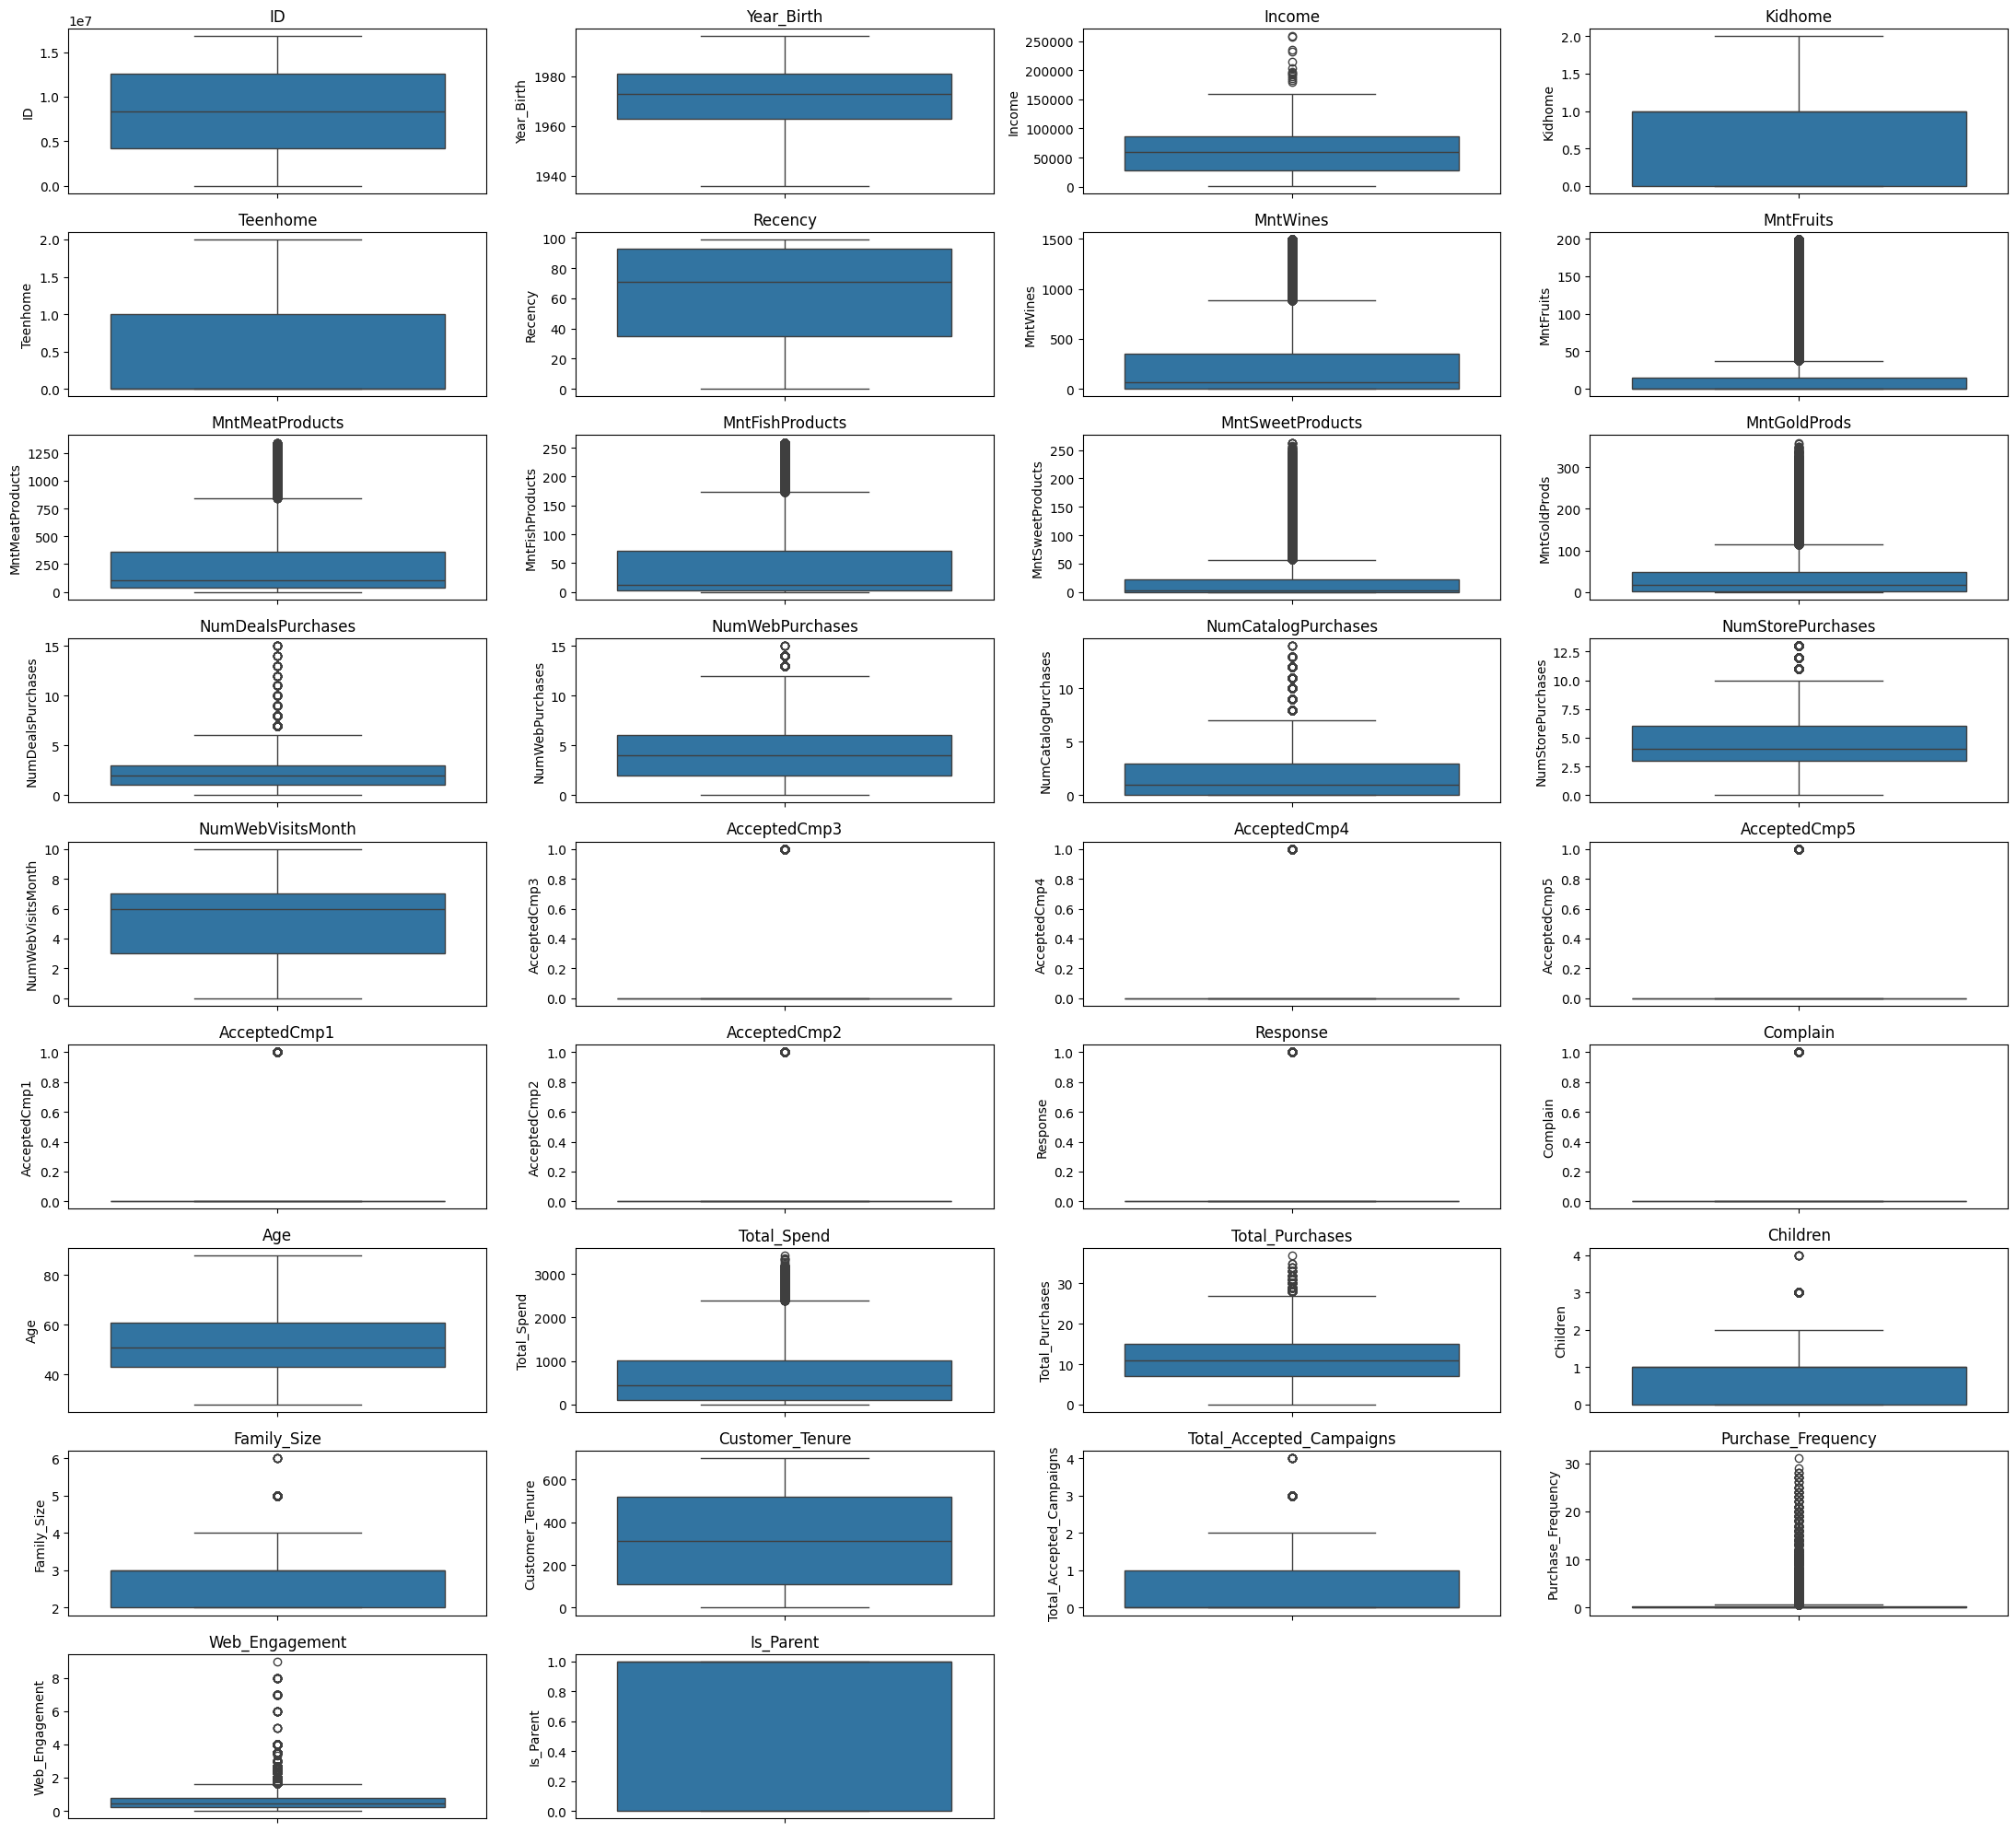

In [205]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 4
n_rows = math.ceil(
    len(num_cols) / n_cols
)

plt.figure(figsize=(22,20))

for i, col in enumerate(num_cols, 1):
    
    plt.subplot(
        n_rows,
        n_cols,
        i
    )
    
    sns.boxplot(
        y=df[col]
    )
    
    plt.title(col)

plt.tight_layout()
plt.show()

Outliers Need to handel which coloumns?

These are Countinuous/numeric features (Outlier is present)
Income
MntWines
MntFruits
MntMeatProducts
MntFishProducts
MntSweetProducts
MntGoldProds
NumDealsPurchases
NumWebPurchases
NumCatalogPurchases
NumStorePurchases
Total_Spend
Total_Purchases

Binary/counts/Normal_distribution Meangiful features
Year_Birth → normal l
Kidhome → 0,1,2 values (categorical count)
Teenhome → categorical count
Recency → normal
NumWebVisitsMonth → normal
AcceptedCmp1–5 → binary (0/1)
Response → binary
Complain → binary
Age → normal, no outlier
Children → count data (0–4 realistic)


For EDA The Best Approch Is Capping(Winsorization),DataLoss when we remove Outliers.
Best option to Cap it

In [206]:
num_cols = num_cols.drop("ID")

In [207]:
df.to_csv("../data/Feature Engineering_Marketing_campaign.csv")
print("data Save....")

data Save....


Check Skewness of Numerical columns

In [208]:
skew_cols = [
    
    'Income',
    'Age',
    'Recency',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth',
    'Total_Spend',
    'Total_Purchases',
    'Children',
    'Family_Size',
    'Customer_Tenure',
    'Total_Accepted_Campaigns',
    'Purchase_Frequency',
    'Web_Engagement'

  ]
# Skewness check
skewness = df[skew_cols].skew().sort_values(ascending=False)

print(skewness)

Purchase_Frequency          8.471692
Web_Engagement              3.307899
MntFruits                   2.948784
MntSweetProducts            2.591677
MntGoldProds                2.457037
MntWines                    1.755128
Total_Accepted_Campaigns    1.734178
MntFishProducts             1.671794
MntMeatProducts             1.600063
NumDealsPurchases           1.594838
NumCatalogPurchases         1.573386
NumWebPurchases             1.103284
Total_Spend                 1.096305
NumStorePurchases           0.631243
Total_Purchases             0.495385
Children                    0.307636
Family_Size                 0.307636
Age                         0.252221
Customer_Tenure             0.057826
Income                     -0.072421
Recency                    -0.429311
NumWebVisitsMonth          -0.595963
dtype: float64


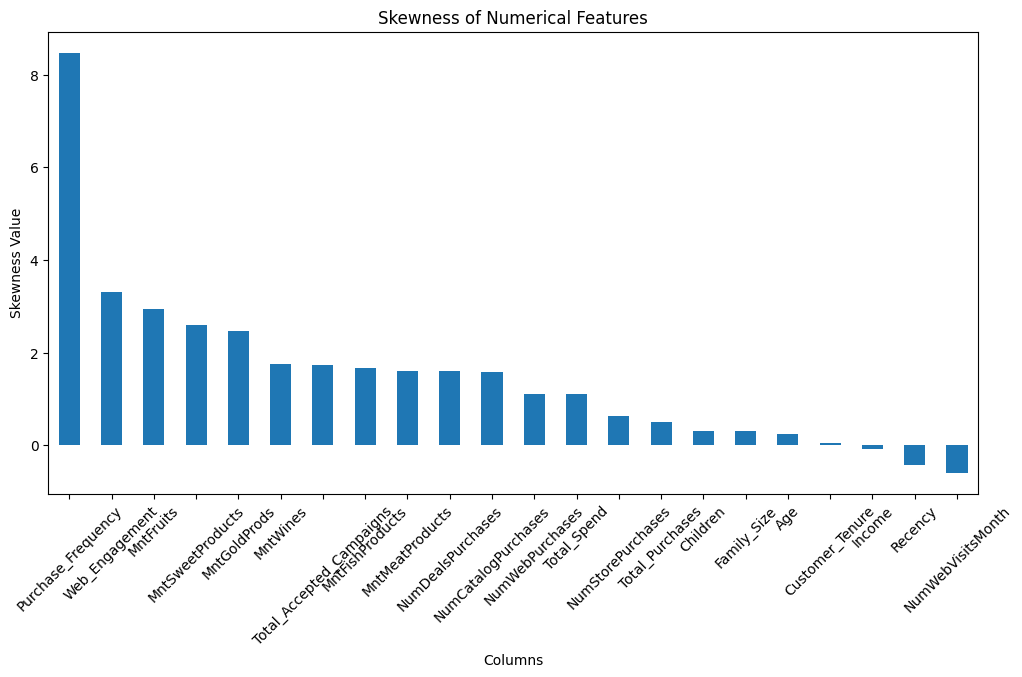

In [209]:
import matplotlib.pyplot as plt

# Skewness calculate
skewness = (
    df[skew_cols]
    .skew()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(12,6))

skewness.plot(kind="bar")

plt.title("Skewness of Numerical Features")
plt.xlabel("Columns")
plt.ylabel("Skewness Value")

plt.xticks(rotation=45)

plt.show()

Rule:
|skewness| < 0.5 → normal
0.5–1 → moderate skew
> 1 → highly skewed (transform kar sakte ho)

 Very Highly Skewed (> 2)
Purchase_Frequency → 8.47 ⚠️
Web_Engagement → 3.30 ⚠️


Highly Skewed (1 – 2)
Total_Accepted_Campaigns
MntFruits
MntFishProducts
MntGoldProds
MntWines
MntSweetProducts
MntMeatProducts
NumCatalogPurchases
NumWebPurchases




Moderate Skew (0.5 – 1)
Total_Spend
NumDealsPurchases
NumWebVisitsMonth (negative skew)

Normal / Acceptable (< 0.5)
Total_Purchases
NumStorePurchases
Children
Family_Size
Age
Customer_Tenure
Income
Recency

This Project is Only to Anaysis the Data Throuh EDA so need Not to handle the Skewness

1.In EDA Project Skweness treatment is not mandatory
because:
  This project is for analysis not for predication
  Business insights are important
  High Spender show Actual values of Business

If i give Skewness Treatment 
 Reduce the arificially impact of high Spender customer

“Since this was primarily an EDA and business analytics project, I preserved the original distribution to retain meaningful customer spending behavior and business insights.”


Only Skweness is check for the Analysis